# Clustering - Kümeleme
 Bu projede ABD'deki ~1000 sektörü (NAICS-6) sera gazı emisyon faktörlerine göre benzerliklerine göre ayıracağız.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns

In [2]:
df=pd.read_csv('ghg_data.csv')

In [3]:
df.sample()

,2017 NAICS Code,2017 NAICS Title,GHG,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Reference USEEIO Code
729,523140,Commodity Contracts Brokerage,All GHGs,"kg CO2e/2022 USD, purchaser price",0.043,0.0,0.043,523A00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   2017 NAICS Code                                1016 non-null   int64  
 1   2017 NAICS Title                               1016 non-null   object 
 2   GHG                                            1016 non-null   object 
 3   Unit                                           1016 non-null   object 
 4   Supply Chain Emission Factors without Margins  1016 non-null   float64
 5   Margins of Supply Chain Emission Factors       1016 non-null   float64
 6   Supply Chain Emission Factors with Margins     1016 non-null   float64
 7   Reference USEEIO Code                          1016 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 63.6+ KB


In [5]:
x=df[['Supply Chain Emission Factors without Margins','Margins of Supply Chain Emission Factors','Supply Chain Emission Factors with Margins']]
x.columns=['without_margins','margins','with_margins']

In [6]:
x.describe()

,without_margins,margins,with_margins
count,1016.000000,1016.000000,1016.000000
mean,0.264994,0.016945,0.281898
std,0.314768,0.023367,0.321417
min,0.026000,0.000000,0.029000
25%,0.103000,0.000000,0.108000
50%,0.159000,0.000000,0.173000
75%,0.302250,0.030250,0.329250
max,3.846000,0.125000,3.924000


In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xs=pd.DataFrame(scaler.fit_transform(x),columns=x.columns)

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [9]:
model=KMeans(4)

In [10]:
model=model.fit(xs)

In [11]:
tahmin=model.predict(xs)

In [12]:
x['cluster']=tahmin

In [13]:
x.head()

,without_margins,margins,with_margins,cluster
0,0.488,0.044,0.532,0
1,0.488,0.044,0.532,0
2,0.809,0.040,0.848,3
3,0.809,0.040,0.848,3
4,0.809,0.040,0.848,3


<Axes: xlabel='cluster', ylabel='count'>

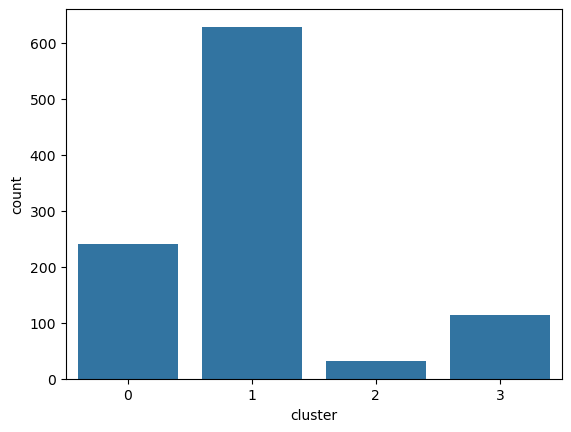

In [14]:
sns.countplot(x=x['cluster'])

In [15]:
silhouette_score(xs, tahmin)

0.5727024809235082

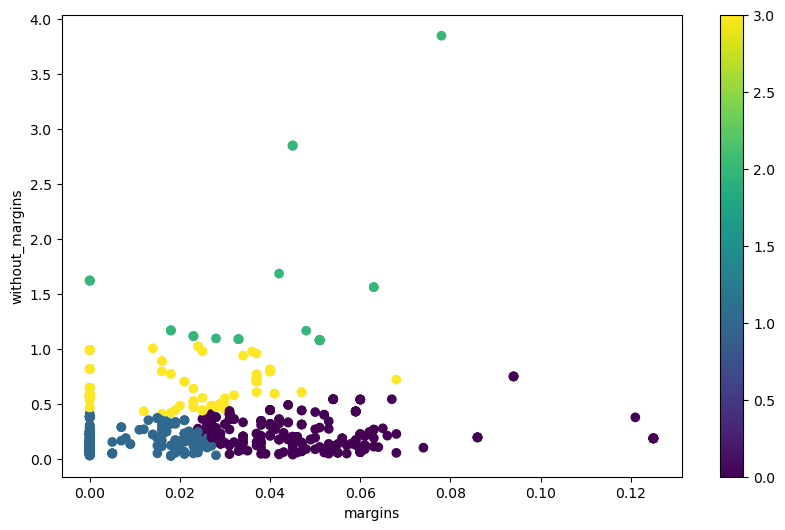

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(x.margins,x.without_margins, c=tahmin)
plt.xlabel('margins')
plt.ylabel('without_margins')
plt.colorbar()

In [17]:
# wcss = within cluster sum of squares
wcss = []
ss = []
for i in range(2, 10):
    model = KMeans(i)
    model = model.fit(xs)
    tahmin = model.predict(xs)
    ss1 = silhouette_score(xs, tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.5830431986231727
0.5575228035936599
0.5682030343553504
0.5761685944589144
0.5780882676523652
0.5822460751431969
0.5830609110092964
0.5811015922018976


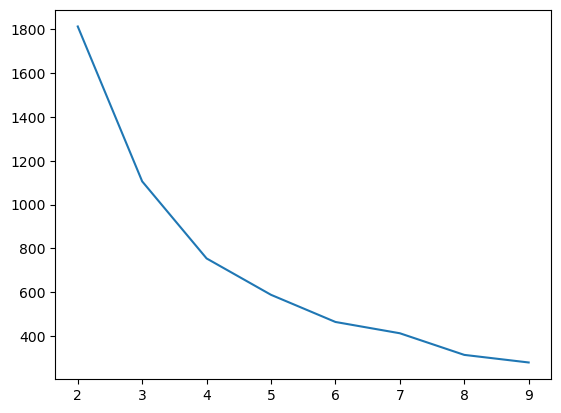

In [18]:
plt.plot(range(2,10),wcss)  #dirsek nerede kırılırsa optimum grup oradadır.

In [19]:
from yellowbrick.cluster import KElbowVisualizer

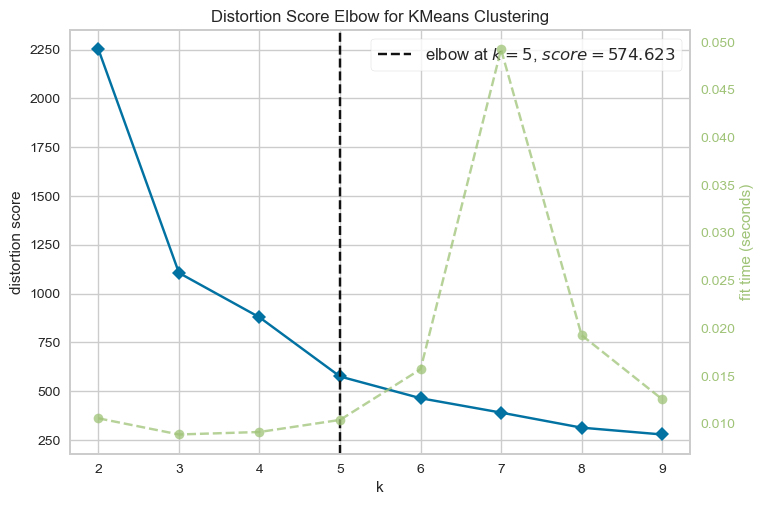

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
vis=KElbowVisualizer(KMeans(),k=(2,10))
vis.fit(xs)
vis.show()

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [22]:
data=linkage(xs,method='ward',metric='euclidean')

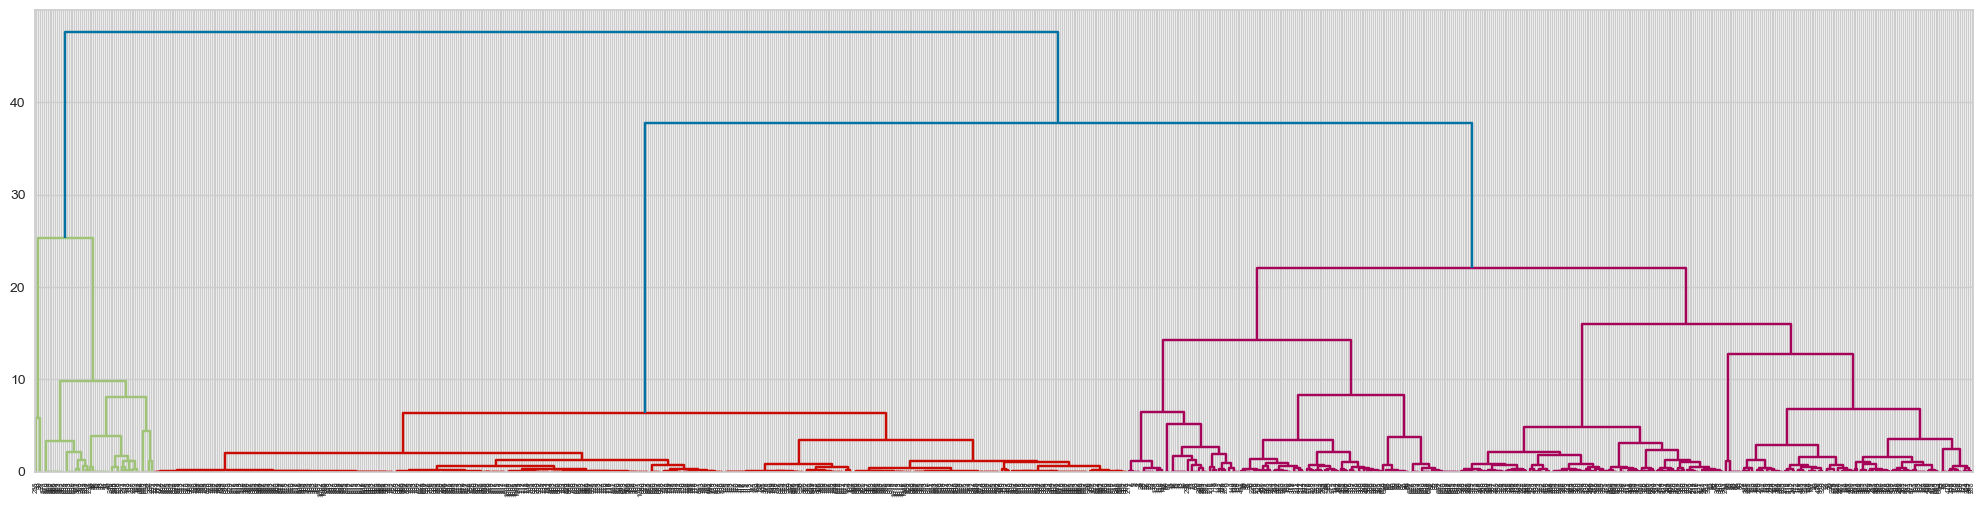

In [23]:
plt.figure(figsize=(25,6))
dendrogram(data);

In [24]:
from sklearn.cluster import DBSCAN

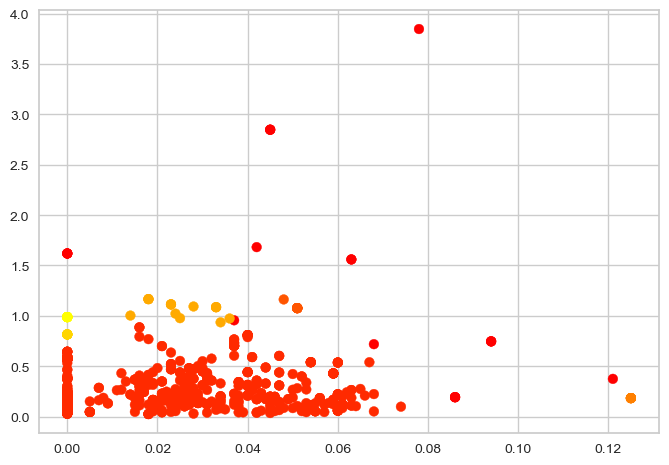

In [25]:
db = DBSCAN(min_samples=5)
y = db.fit_predict(xs)

plt.scatter(x['margins'], x['without_margins'], c=y, cmap='autumn')
plt.savefig('clustering.png', dpi=300)

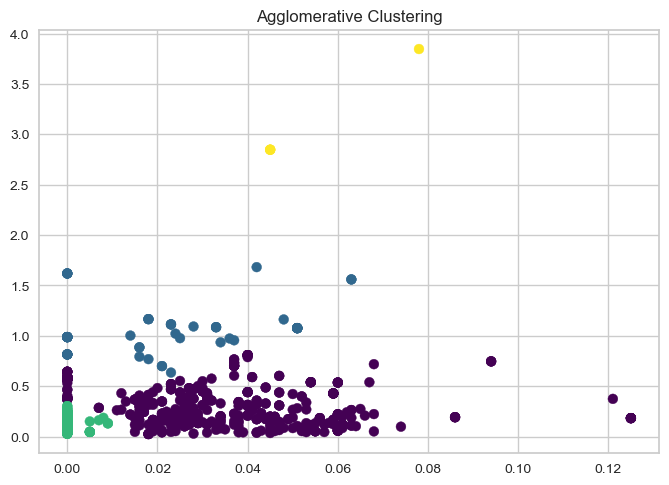

In [26]:
from sklearn.cluster import AgglomerativeClustering
agg_clustering = AgglomerativeClustering(n_clusters=4)
y_agg = agg_clustering.fit_predict(xs)

# Plot the results
plt.scatter(x.margins, x.without_margins, c=y_agg, s=50, cmap='viridis')
plt.title('Agglomerative Clustering')
plt.show()

In [27]:
import pickle
son_model=KMeans(4, random_state=42).fit(xs)
pickle.dump(son_model,open('ghg_kmeans.pkl','wb'))
pickle.dump(scaler,open('ghg_scaler.pkl','wb'))

In [28]:
# her kümenin ortalama değerleri (uygulamada yorum için)
xs['cluster']=son_model.labels_
x['cluster']=son_model.labels_
x.groupby('cluster').mean()

,without_margins,margins,with_margins
cluster,,,
0,0.191981,0.048116,0.240084
1,1.296429,0.027735,1.324265
2,0.543688,0.026026,0.569526
3,0.134958,0.002515,0.137448
